# Latent Dirichlet Allocation

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

## Dataset

*  The dataset is using articles from NPR (National Public Radio), obtained from their website - [npr.org](http://www.npr.org)



In [ ]:
npr = pd.read_csv('npr.csv')

In [ ]:
npr.head()

,Article
0,"In the Washington of 2016, even when the polic..."
1,Donald Trump has used Twitter — his prefe...
2,Donald Trump is unabashedly praising Russian...
3,"Updated at 2:50 p. m. ET, Russian President Vl..."
4,"From photography, illustration and video, to d..."


## Creating the Bag of Words model

**`max_df`**` : float in range [0.0, 1.0] or int, default=1.0`<br>
When building the vocabulary ignore terms that have a document frequency strictly higher than the given threshold (corpus-specific stop words). If float, the parameter represents a proportion of documents, integer absolute counts. This parameter is ignored if vocabulary is not None.
<br>
<br>
**`min_df`**` : float in range [0.0, 1.0] or int, default=1`<br>
When building the vocabulary ignore terms that have a document frequency strictly lower than the given threshold. This value is also called cut-off in the literature. If float, the parameter represents a proportion of documents, integer absolute counts. This parameter is ignored if vocabulary is not None.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_df = 0.95, min_df = 2, stop_words = 'english')
dtm = cv.fit_transform(npr['Article'])

In [ ]:
dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3033388 stored elements and shape (11992, 54777)>

## Caculating perplexities for LDA

In [52]:
from sklearn.decomposition import LatentDirichletAllocation as lda

In [53]:
topic_range = range(1, 12)
likelihoods = []

for i in topic_range:
  LDA = lda(n_components = i, random_state = 42)
  LDA.fit(dtm)
  likelihoods.append(LDA.score(dtm))

## Visualizing Elbow Method

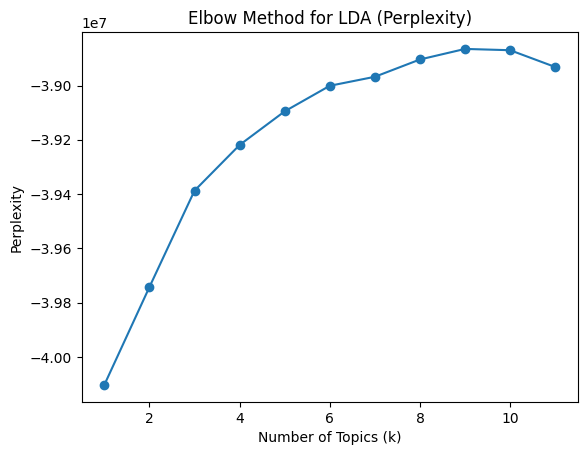

In [54]:
plt.plot(list(topic_range), likelihoods, marker = 'o')
plt.xlabel("Number of Topics (k)")
plt.ylabel("Perplexity")
plt.title("Elbow Method for LDA (Perplexity)")
plt.show()

## Creating and Training the LDA Model

In [55]:
LDA = lda(n_components = 9, random_state = 42)
LDA.fit(dtm)

LatentDirichletAllocation(n_components=9, random_state=42)

## Visualizing stored words

In [56]:
feature_len = len(cv.get_feature_names_out())
print(feature_len)

54777


In [57]:
for i in range(10):
    random_word_id = random.randint(0, feature_len)
    print(cv.get_feature_names_out()[random_word_id])

meese
vegetal
confirm
kamaal
magenta
arafat
condolence
balanced
bupropion
districtwide


In [58]:
for i in range(10):
    random_word_id = random.randint(0, feature_len)
    print(cv.get_feature_names_out()[random_word_id])

birdsong
christian
sailboats
insubstantial
trader
marital
servant
stuns
emmys
valuable


## Visualizing Top Words Per Topic

In [59]:
print(len(LDA.components_))
print(len(LDA.components_[0]))

9
54777


In [60]:
print(LDA.components_)

[[5.14350854e+00 1.96675455e+03 1.11117650e-01 ... 1.11227129e-01
  1.11111111e-01 1.11111971e-01]
 [8.09580483e+00 1.17359191e+02 1.11111111e-01 ... 1.11111112e-01
  1.11111111e-01 1.11114218e-01]
 [3.92418863e+00 5.56788863e+02 1.11111111e-01 ... 1.15689749e-01
  2.11089722e+00 1.11126129e-01]
 ...
 [1.26699266e+01 3.55606484e+02 1.11111111e-01 ... 1.11111112e-01
  1.11217805e-01 1.11112413e-01]
 [2.68444364e+01 5.49094603e+02 1.11111111e-01 ... 1.11145091e-01
  1.11111111e-01 1.11111111e-01]
 [1.11188139e-01 3.12877152e+02 1.11111111e-01 ... 4.93753496e+00
  1.11120527e-01 1.11112769e-01]]


In [61]:
single_topic = LDA.components_[0]

In [62]:
top_word_indices = single_topic.argsort()[-10:]

In [63]:
for index in top_word_indices:
    print(cv.get_feature_names_out()[index])

000
federal
new
money
companies
million
company
health
said
says


## Getting top 15 words from every topic

In [64]:
for index, topic in enumerate(LDA.components_):
    print('\n')
    print(f'THE TOP 15 WORDS FOR TOPIC #{index + 1}')
    print([cv.get_feature_names_out()[i] for i in topic.argsort()[-15:]])



THE TOP 15 WORDS FOR TOPIC #1
['care', 'people', 'government', 'insurance', 'year', '000', 'federal', 'new', 'money', 'companies', 'million', 'company', 'health', 'said', 'says']


THE TOP 15 WORDS FOR TOPIC #2
['npr', 'new', 'military', 'told', 'russian', 'campaign', 'security', 'obama', 'white', 'news', 'russia', 'house', 'president', 'said', 'trump']


THE TOP 15 WORDS FOR TOPIC #3
['make', 'family', 'way', 'home', 'water', 'day', 'world', 'time', 'years', 'new', 'food', 'people', 'just', 'like', 'says']


THE TOP 15 WORDS FOR TOPIC #4
['new', 'don', 'percent', 'medical', 'children', 'disease', 'just', 'care', 'patients', 'like', 'study', 'women', 'health', 'people', 'says']


THE TOP 15 WORDS FOR TOPIC #5
['supreme', 'order', 'states', 'city', 'federal', 'president', 'country', 'rights', 'government', 'law', 'state', 'people', 'said', 'court', 'says']


THE TOP 15 WORDS FOR TOPIC #6
['going', 'story', 've', 'don', 'life', 'new', 'way', 'really', 'time', 'music', 'know', 'think', 

## Inferencing on the training set

In [65]:
topic_results = LDA.transform(dtm)

In [66]:
topic_results[0].argmax()

np.int64(1)

## Visualizing with training set

In [67]:
topic_results.argmax(axis = 1)

array([1, 1, 1, ..., 3, 8, 4])

In [68]:
npr['Topic'] = topic_results.argmax(axis = 1)

In [69]:
npr.head(10)

,Article,Topic
0,"In the Washington of 2016, even when the polic...",1
1,Donald Trump has used Twitter — his prefe...,1
2,Donald Trump is unabashedly praising Russian...,1
3,"Updated at 2:50 p. m. ET, Russian President Vl...",1
4,"From photography, illustration and video, to d...",6
5,I did not want to join yoga class. I hated tho...,3
6,With a who has publicly supported the debunk...,3
7,"I was standing by the airport exit, debating w...",2
8,"If movies were trying to be more realistic, pe...",3
9,"Eighteen years ago, on New Year’s Eve, David F...",2
